# Lecture 10, Supplement 1 — Three ways to say "that is not normal"

### mean ± kσ, isolation forest and PCA reconstruction error — from the ground up

**01211271 Industrial AI and IoT** · Electromechanical Manufacturing Engineering

---

Section 7 of Lecture 10 fitted three anomaly detectors in one cell and put their scores in
a table:

| detector | ROC-AUC | bearing caught | imbalance caught |
|---|---|---|---|
| mean ± kσ | 0.959 | 0.514 | 0.993 |
| isolation forest | 0.963 | 0.577 | 0.954 |
| PCA residual | 0.943 | 0.637 | 0.557 |

That table is correct, and it is almost impossible to understand if you have not met the
three methods before. This notebook takes them apart one at a time. By the end you should
be able to say, for each one, **what shape it thinks "normal" is**, and so predict which
faults it will catch and which it will miss **before** you run it.

This is background for Lecture 10 — not new examinable material.

### The plan

1. What "normal" means for one feature, and why the threshold is a quantile, not 3σ.
2. **mean ± kσ** — a box.
3. **Mahalanobis distance** — an ellipse. Not in Lecture 10; it is the bridge between the
   box and PCA, and on this rig it beats all three.
4. **isolation forest** — a game of random cuts.
5. **PCA reconstruction error** — a strip, and the half of PCA that Lecture 10 did not use.
6. All four on the rig, reproducing Lecture 10's table to the digit.
7. What happens when your "healthy" training data is not quite healthy.

Every method is shown first on **two features you can see** — `rms` and `ptp` — and then on
all twelve.

### Prerequisites

`rig.py` and `detectors.py` in the same folder as this notebook, both in
`Lecture10_Supplement1_Code.zip`. `rig.py` is exactly Lecture 10's file.

In [1]:
import platform
import numpy as np
import matplotlib.pyplot as plt
import sklearn

import rig
import detectors as D

print("python", platform.python_version(), "· numpy", np.__version__,
      "· scikit-learn", sklearn.__version__)

GREY, BLUE, AQUA, ORANGE, VIOLET, RED = ("#b9b8b0", "#2a78d6", "#1baf7a",
                                         "#eb6834", "#4a3aa7", "#e34948")
plt.rcParams.update({"figure.figsize": (10.5, 3.6), "axes.grid": True,
                     "grid.alpha": 0.35, "axes.spines.top": False,
                     "axes.spines.right": False})

python 3.11.15 · numpy 2.4.4 · scikit-learn 1.8.0


## 0. The job, in one sentence

We have thousands of windows from **healthy** machines and almost none from faulty ones.
So we cannot learn what a fault looks like. We can only learn what *healthy* looks like,
and then, for every new window, answer:

> **How unlike healthy is this?**

Every method in this notebook has the same two steps, and it is worth holding them apart:

| step | what it is | who decides |
|---|---|---|
| **score** | one number per window: how odd | the method |
| **threshold** | "odd enough to act on" | **you** — a quantile of healthy scores |

The four methods differ only in the first step. The second step — and it is the one that
decides your false-alarm rate — is identical for all of them.

In [2]:
fleet = rig.make_fleet(seed=23)                  # Lecture 10's fleet, unchanged
X, y, groups = rig.build_table(fleet)
F = list(rig.FEATURE_NAMES)
NRM, IMB, BRG = y == "normal", y == "imbalance", y == "bearing"

print(f"{len(y):,} windows x {X.shape[1]} features")
for lab in ("normal", "imbalance", "bearing"):
    print(f"  {lab:<10} {(y == lab).sum():>5,} windows")

9,150 windows x 12 features
  normal     8,052 windows
  imbalance    732 windows
  bearing      366 windows


For the pictures we use two features: `rms` (overall vibration level) and `ptp`
(peak-to-peak). They are strongly correlated on a healthy machine — correlation
**0.88** — because a machine that vibrates more overall also swings
further. Hold on to that correlation; it decides the first half of this notebook.

We measure both in **healthy standard deviations**: subtract the healthy mean, divide by
the healthy standard deviation. That is a *z-score*, and it puts every feature on the same
ruler.

correlation of rms and ptp on healthy windows: 0.882


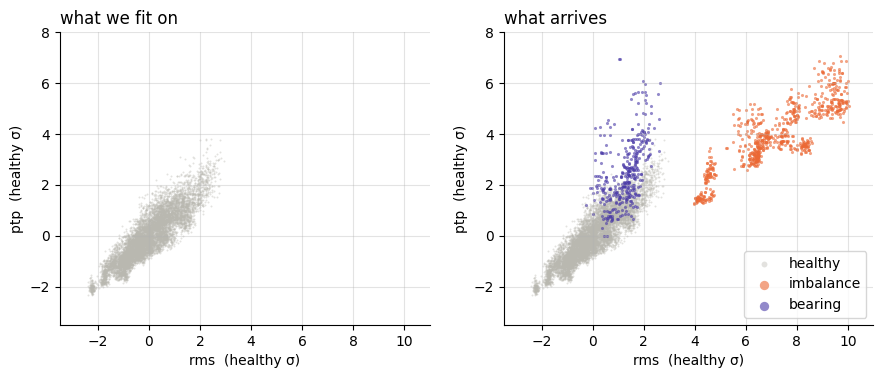

In [3]:
C2 = [F.index("rms"), F.index("ptp")]
X2 = X[:, C2]
mu2, sd2 = X2[NRM].mean(0), X2[NRM].std(0)
Z2 = (X2 - mu2) / sd2                            # z-scores against HEALTHY data
print("correlation of rms and ptp on healthy windows:",
      round(np.corrcoef(X2[NRM].T)[0, 1], 3))

def cloud(ax, faults=True):
    ax.scatter(Z2[NRM, 0], Z2[NRM, 1], s=2, c=GREY, alpha=0.4, lw=0, label="healthy")
    if faults:
        ax.scatter(Z2[IMB, 0], Z2[IMB, 1], s=5, c=ORANGE, alpha=0.6, lw=0, label="imbalance")
        ax.scatter(Z2[BRG, 0], Z2[BRG, 1], s=5, c=VIOLET, alpha=0.6, lw=0, label="bearing")
    ax.set_xlabel("rms  (healthy σ)"); ax.set_ylabel("ptp  (healthy σ)")

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8))
cloud(ax[0], faults=False); ax[0].set_title("what we fit on", loc="left")
cloud(ax[1]); ax[1].set_title("what arrives", loc="left"); ax[1].legend(markerscale=3)
for a in ax: a.set_xlim(-3.5, 11); a.set_ylim(-3.5, 8)
plt.show()

Two different faults, two different ways of leaving the cloud:

* **imbalance** walks far out along `rms` — a big 1× shaft line makes everything bigger;
* **bearing** stays at an ordinary `rms` but its `ptp` is too high *for that rms* — the
  spall adds sharp impulses that raise the peaks without adding much energy.

The second one is the hard one, and it is the one each method handles differently.

## 1. What "normal" means for one feature

Take a single feature and compute its mean $\mu$ and standard deviation $\sigma$ over
healthy windows. A new window's value $x$ becomes

$$z = \frac{x - \mu}{\sigma}$$

— how many standard deviations it sits from the healthy average.

You have probably been told that "beyond 3σ" happens 0.27 % of the time. That is true
**for a Gaussian** and for nothing else. Here are two of our features:

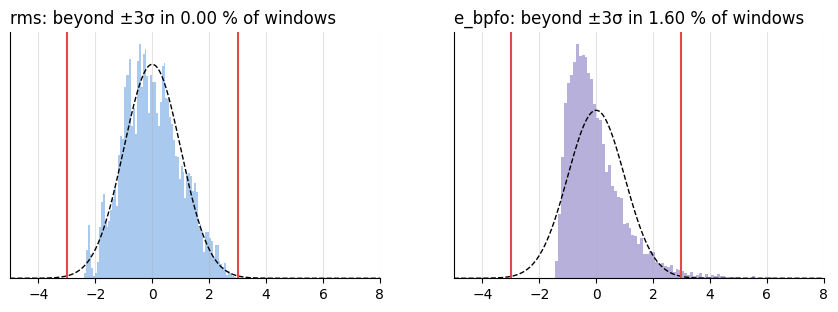

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.2))
for a, name, col in ((ax[0], "rms", BLUE), (ax[1], "e_bpfo", VIOLET)):
    v = X[NRM, F.index(name)]
    z = (v - v.mean()) / v.std()
    a.hist(z, bins=80, density=True, color=col, alpha=0.4)
    g = np.linspace(-5, 8, 300)
    a.plot(g, np.exp(-g**2 / 2) / np.sqrt(2 * np.pi), "k--", lw=1)
    for s in (-3, 3): a.axvline(s, color=RED)
    a.set_title(f"{name}: beyond ±3σ in {(np.abs(z) > 3).mean()*100:.2f} % of windows",
                loc="left")
    a.set_xlim(-5, 8); a.set_yticks([])
plt.show()

`rms` is symmetric with light tails: **0.00 %** of
healthy windows lie beyond 3σ. `e_bpfo` is skewed — a long tail on one side — and
**1.60 %** do, six times the Gaussian figure.

Same "3σ", very different false-alarm rates. That is why, from here on, a threshold is
never "k = 3". It is **a quantile of the healthy scores** — "the value only 1 % of healthy
windows exceed" — which gives you the false-alarm rate you asked for whatever shape the
data has.

## 2. Method 1 — mean ± kσ: a box

With twelve features, each window has twelve z-scores. The simplest score is the worst of
them:

$$\text{score} = \max_j |z_j|$$

"How many standard deviations out is the feature that is furthest out?" Here it is in full
— it is the detector Lecture 11 puts on the ESP32, and this is the whole of it:

In [5]:
class ZScore:
    """max |z| over features.  25 numbers on the device: 12 means, 12 sigmas,
    one threshold -- which is why it is the detector Lecture 11 deploys."""

    def fit(self, H):
        self.mu = H.mean(axis=0)
        self.sd = H.std(axis=0)
        self.sd[self.sd == 0] = 1.0
        return self

    def z(self, X):
        return (X - self.mu) / self.sd

    def score(self, X):
        return np.abs(self.z(X)).max(axis=1)

    def driver(self, X, names):
        """Which feature is furthest out -- the name an engineer can act on."""
        return [names[i] for i in np.abs(self.z(X)).argmax(axis=1)]

In [6]:
# Lecture 10's protocol: each window scored by a detector fitted on OTHER runs'
# healthy windows (5 grouped folds).  Reproduces the Lecture 10 table exactly.
oof = D.oof_scores(X, y, groups, extra=True)
s = oof["S"]["mean ± kσ"]

print(f"k = 3   flags {(s[NRM] > 3).mean()*100:.1f} % of healthy windows")
print(f"        that is one false alarm every "
      f"{1 / ((s[NRM] > 3).mean() * rig.FS / rig.HOP):.1f} s at 15.6 windows/s")
k99 = np.quantile(s[NRM], 0.99)
print(f"\nthe 99th percentile of healthy scores:  k = {k99:.2f}")
print(f"a Gaussian with 12 independent features would give "
      f"{(1 - 0.9973**12)*100:.1f} % beyond 3σ")

k = 3   flags 4.1 % of healthy windows
        that is one false alarm every 1.6 s at 15.6 windows/s

the 99th percentile of healthy scores:  k = 4.04
a Gaussian with 12 independent features would give 3.2 % beyond 3σ


Two reasons k = 3 is wrong here, and both are general:

1. **Twelve chances.** The score is the *maximum* of twelve z-scores, so a healthy window
   gets twelve chances to have one of them land beyond 3. Even for perfectly Gaussian,
   independent features that happens 3.2 % of the time.
2. **Skew.** Features like `e_bpfo` have long tails and add more.

The data's own answer is **k = 4.04**, which is exactly the threshold in
Lecture 10's alarm specification.

### What the box looks like

In two dimensions, "max |z| ≤ k" is a **square**: both z-scores must stay within ±k.

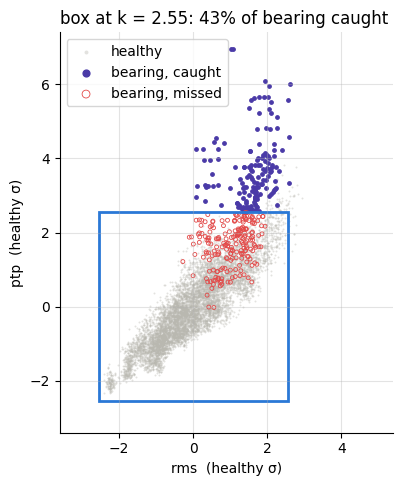

In [7]:
dz = D.ZScore().fit(X2[NRM]); sz = dz.score(X2)
kz = np.quantile(sz[NRM], 0.99)

fig, ax = plt.subplots(figsize=(6.2, 5.2))
cloud(ax, faults=False)
caught = BRG & (sz > kz)
ax.scatter(Z2[caught, 0], Z2[caught, 1], s=6, c=VIOLET, label="bearing, caught")
ax.scatter(Z2[BRG & ~caught, 0], Z2[BRG & ~caught, 1], s=8, facecolors="none",
           edgecolors=RED, lw=0.6, label="bearing, missed")
ax.add_patch(plt.Rectangle((-kz, -kz), 2 * kz, 2 * kz, fill=False, ec=BLUE, lw=2))
ax.set_xlim(-3.6, 5.4); ax.set_ylim(-3.4, 7.4); ax.set_aspect("equal")
ax.legend(loc="upper left", markerscale=2)
ax.set_title(f"box at k = {kz:.2f}: {caught.sum() / BRG.sum():.0%} of bearing caught",
             loc="left")
plt.show()

Look at where the box sits relative to the cloud. The healthy data is a **tilted** cigar;
the box is **square**. Its top-left and bottom-right corners contain no healthy data at all
— and the top-left corner, "ordinary rms, high ptp", is exactly where the bearing windows
are. The box calls them healthy because each feature *separately* is within range. Only
**43%** are caught.

The box cannot see that the two features are wrong **together**.

## 3. The bridge — Mahalanobis distance: an ellipse

Mahalanobis distance asks the same question — how many standard deviations out? — but of
all the features at once, allowing for the fact that they move together:

$$\text{score} = \sqrt{\,\mathbf z^\top C^{-1} \mathbf z\,}$$

where $\mathbf z$ is the vector of z-scores and $C$ is the healthy **correlation matrix**.
You do not need the algebra to use it. What it does geometrically is replace the box with
an **ellipse that leans the same way the data does**: being far along the cigar is cheap,
being far *across* it is expensive.

In [8]:
class Mahalanobis:
    """sqrt( z^T  C^-1  z ) with C the healthy correlation matrix.

    Where max|z| draws a BOX around the healthy data, this draws an ELLIPSE
    that leans the same way the data does.  The price: C must be invertible,
    and on this rig it is not -- `rms` and `std` are the same number once the
    mean is removed -- so we use the pseudo-inverse, which quietly ignores any
    direction the healthy data never moves in.
    """

    def fit(self, H):
        self.mu = H.mean(axis=0)
        self.sd = H.std(axis=0)
        self.sd[self.sd == 0] = 1.0
        Z = (H - self.mu) / self.sd
        self.C = np.cov(Z, rowvar=False)
        self.P = np.linalg.pinv(self.C, rcond=1e-10)
        self.rank = int(np.linalg.matrix_rank(self.C, tol=1e-10))
        return self

    def score(self, X):
        Z = (X - self.mu) / self.sd
        return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", Z, self.P, Z), 0.0))

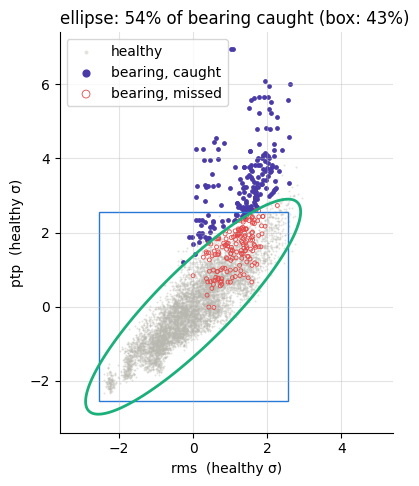

In [9]:
dm = D.Mahalanobis().fit(X2[NRM]); sm = dm.score(X2)
km = np.quantile(sm[NRM], 0.99)

gx, gy = np.meshgrid(np.linspace(-3.6, 5.4, 300), np.linspace(-3.4, 7.4, 300))
grid = np.column_stack([gx.ravel(), gy.ravel()]) * sd2 + mu2

fig, ax = plt.subplots(figsize=(6.2, 5.2))
cloud(ax, faults=False)
caught = BRG & (sm > km)
ax.scatter(Z2[caught, 0], Z2[caught, 1], s=6, c=VIOLET, label="bearing, caught")
ax.scatter(Z2[BRG & ~caught, 0], Z2[BRG & ~caught, 1], s=8, facecolors="none",
           edgecolors=RED, lw=0.6, label="bearing, missed")
ax.contour(gx, gy, dm.score(grid).reshape(gx.shape), levels=[km], colors=[AQUA],
           linewidths=2)
ax.add_patch(plt.Rectangle((-kz, -kz), 2 * kz, 2 * kz, fill=False, ec=BLUE, lw=1))
ax.set_xlim(-3.6, 5.4); ax.set_ylim(-3.4, 7.4); ax.set_aspect("equal")
ax.legend(loc="upper left", markerscale=2)
ax.set_title(f"ellipse: {caught.sum() / BRG.sum():.0%} of bearing caught "
             f"(box: {(BRG & (sz > kz)).sum() / BRG.sum():.0%})", loc="left")
plt.show()

Same false-alarm rate — both thresholds are the 99th percentile of healthy scores — and
the ellipse catches **54%** of bearing windows against the box's
**43%**. Nothing about the data changed; only the shape of "normal".

### A trap you will hit on the full rig

On all twelve features, $C$ **cannot be inverted**. `rms` and `std` are the same number
once the mean is removed (the difference is about $10^{-16}$), so two rows of $C$ are
identical and its rank is **11 of 12**. `np.linalg.inv` will either fail or,
worse, return enormous garbage. We use the **pseudo-inverse**, which quietly ignores any
direction the healthy data never moves in.

That is the first sign of an idea PCA makes explicit: twelve features do not mean twelve
independent directions.

In [10]:
m12 = D.Mahalanobis().fit(X[NRM])
print("largest |rms - std| over all windows:", np.abs(X[:, 1] - X[:, 2]).max())
print("rank of the 12 x 12 healthy correlation matrix:", m12.rank)

largest |rms - std| over all windows: 1.1102230246251565e-16
rank of the 12 x 12 healthy correlation matrix: 11


## 4. Method 2 — isolation forest: a game of random cuts

The isolation forest assumes nothing about shape. It plays a game:

1. pick a feature at random;
2. pick a cut value at random, somewhere between the smallest and largest value still in
   play;
3. keep only the side that holds the window you are interested in;
4. repeat until that window is alone.

**Count the cuts.** An odd window, out on its own, is fenced off in a few cuts. An ordinary
one, buried in the crowd, takes many. Here is the game played by hand on
61 points:

In [11]:
def iso_path(P, target, rng):
    '''Play the cutting game for one point; return how many cuts it took.'''
    idx = np.arange(len(P))
    cuts = 0
    while len(idx) > 1:
        j = rng.integers(P.shape[1])                     # a random feature
        lo, hi = P[idx, j].min(), P[idx, j].max()
        if hi == lo:
            break
        v = rng.uniform(lo, hi)                          # a random cut
        same_side = (P[idx, j] < v) == (P[target, j] < v)
        idx = idx[same_side]                             # keep the target's side
        cuts += 1
    return cuts

rng = np.random.default_rng(4)
P = rng.multivariate_normal([0, 0], [[1, 0.75], [0.75, 1]], size=60)
P = np.vstack([P, [[2.9, -1.9]]])                        # the odd one out
odd, ordinary = len(P) - 1, int(np.argmin((P[:-1] ** 2).sum(1)))

r = np.random.default_rng(1)
L_odd = np.mean([iso_path(P, odd, r) for _ in range(400)])
L_ord = np.mean([iso_path(P, ordinary, r) for _ in range(400)])
print(f"average cuts to isolate the odd point:      {L_odd:.1f}")
print(f"average cuts to isolate an ordinary point:  {L_ord:.1f}")

average cuts to isolate the odd point:      3.3
average cuts to isolate an ordinary point:  9.7


That is the whole idea. The real `IsolationForest` does the same with 200 random trees,
each built on a random sample of 256 healthy windows, and turns the average number of cuts
into a score between 0 and 1: about 0.5 for an ordinary window, towards 1 for one that is
isolated quickly. We use its negative log-score so that **bigger = odder**, like the other
three.

In [12]:
class IForest:
    """Mean path length to isolate a point, over 200 random trees, turned into
    a score in (0, 1).  Nothing is assumed about the SHAPE of healthy data.

    Lecture 10's settings: standardised features, 200 trees, random_state=0.
    """

    def __init__(self, n_estimators=200, random_state=0, max_samples="auto"):
        self.kw = dict(n_estimators=n_estimators, random_state=random_state,
                       max_samples=max_samples, n_jobs=-1)

    def fit(self, H):
        self.sc = StandardScaler().fit(H)
        self.m = IsolationForest(**self.kw).fit(self.sc.transform(H))
        return self

    def score(self, X):
        return -self.m.score_samples(self.sc.transform(X))

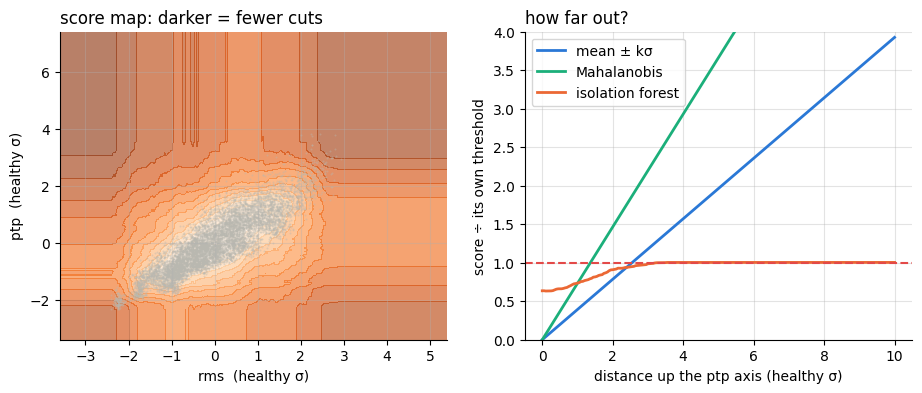

isolation-forest threshold (99th pct of healthy): 0.677
score of a point 30σ out:                         0.680
bearing caught in 2-D: 25%


In [13]:
di = D.IForest().fit(X2[NRM]); si = di.score(X2)
ki = np.quantile(si[NRM], 0.99)

S = di.score(grid).reshape(gx.shape)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].contourf(gx, gy, S, levels=14, cmap="Oranges", alpha=0.6)
cloud(ax[0], faults=False)
ax[0].set_title("score map: darker = fewer cuts", loc="left")

d = np.linspace(0, 10, 201)                        # walk straight up the ptp axis
ray = np.column_stack([np.zeros_like(d), d]) * sd2 + mu2
for name, det, k, col in (("mean ± kσ", dz, kz, BLUE), ("Mahalanobis", dm, km, AQUA),
                          ("isolation forest", di, ki, ORANGE)):
    ax[1].plot(d, det.score(ray) / k, color=col, lw=2, label=name)
ax[1].axhline(1, color=RED, ls="--"); ax[1].set_ylim(0, 4)
ax[1].set_xlabel("distance up the ptp axis (healthy σ)")
ax[1].set_ylabel("score ÷ its own threshold"); ax[1].legend()
ax[1].set_title("how far out?", loc="left")
plt.show()

far = np.array([[0.0, 30.0]]) * sd2 + mu2
print(f"isolation-forest threshold (99th pct of healthy): {ki:.3f}")
print(f"score of a point 30σ out:                         {di.score(far)[0]:.3f}")
print(f"bearing caught in 2-D: {(si[BRG] > ki).mean():.0%}")

Look at the right-hand plot, because it is the most important property of this method.
Walk straight out of the healthy cloud: the z-score and the Mahalanobis distance keep
climbing. The isolation-forest score **flattens** — once a point is outside all the data,
one cut fences it off, and one cut is the minimum. A point 3σ out and a point 30σ out get
the same score.

**The isolation forest knows "outside", not "how far outside".**

In these two dimensions that is fatal: the healthy data's own fringe is already isolated
almost as quickly as it is possible to be, so the 99th percentile of healthy scores
(**0.677**) sits right at the ceiling (**0.680**).
There is almost no room above the threshold, and only **25%** of
bearing windows get into it.

With twelve features there is room — Lecture 10's forest catches 58% of
bearing windows. But twelve features bring a different weakness. Each cut picks **one**
feature at random, and a tree is at most 8 cuts deep, so a window that is extreme in one
feature and ordinary in the other eleven is never tested on its odd feature in about
**50%** of trees:

In [14]:
di12 = D.IForest().fit(X[NRM]); s12 = di12.score(X)
k12 = np.quantile(s12[NRM], 0.99)
dz12 = D.ZScore().fit(X[NRM])
mu, sd = X[NRM].mean(0), X[NRM].std(0)

print("push ONE feature 50σ out, leave the other eleven at their healthy mean:\n")
print(f"  {'feature':<8} {'max |z|':>8}   {'isolation forest ÷ threshold':>28}")
for name in ("kurt", "e_hi", "rms"):
    far = mu.copy(); far[F.index(name)] += 50 * sd[F.index(name)]
    print(f"  {name:<8} {dz12.score(far[None])[0]:8.1f}   "
          f"{di12.score(far[None])[0] / k12:28.2f}")
print(f"\nfor comparison, a real bearing window scores a median "
      f"{np.median(s12[BRG]) / k12:.2f} x the threshold")

push ONE feature 50σ out, leave the other eleven at their healthy mean:

  feature   max |z|   isolation forest ÷ threshold
  kurt         50.0                           0.78
  e_hi         50.0                           0.82
  rms          50.0                           0.78

for comparison, a real bearing window scores a median 1.09 x the threshold


Fifty standard deviations out on one feature, and the forest calls it **healthy**
(about 0.8× its threshold). The z-score detector screams 50.

That is not a bug; it is what random single-feature cuts measure. Real faults usually
move several features together — a spall raises `kurt`, `crest`, `ptp` and `e_hi` at once
— and those the forest isolates well. But a **single broken sensor channel**, or a fault
that shows in exactly one feature, is precisely what it is worst at. Remember that when
someone suggests replacing a simple z-score with a forest because the forest is "more
advanced".

## 5. Method 3 — PCA reconstruction error: a strip

Section 3 showed that the healthy `rms`–`ptp` cloud is really **one direction** with a
little spread around it: 94% of its variance lies along a single line.
Principal Component Analysis finds those directions for you:

1. find the direction along which healthy data varies most — the first **principal
   component**;
2. then the next, at right angles to it, and so on;
3. keep the few that carry most of the variance (Lecture 10 kept enough for 95 %).

To score a window, **project** it onto the kept directions — that is, find the nearest
point that a healthy machine could have produced using only those directions — and measure
how far away it was. That distance is the **residual**, or reconstruction error:

$$\text{residual} = \lVert \mathbf z - \hat{\mathbf z} \rVert$$

"How much of this window can healthy behaviour **not** explain?"

In [15]:
class PCAResidual:
    """Project onto the k directions that carry 95 % of healthy variance,
    reconstruct, and measure what is left over.

    `score` is the residual (the "reconstruction error", or SPE / Q statistic).
    `t2` is the other half PCA offers for free: how far the window sits ALONG
    the kept directions, in units of their own spread.  Lecture 10 used only
    the first, and that is where its blind spot comes from.
    """

    def __init__(self, var=0.95, k=None):
        self.var, self.k_fixed = var, k

    def fit(self, H):
        self.sc = StandardScaler().fit(H)
        A = self.sc.transform(H)
        if self.k_fixed is None:
            cum = np.cumsum(PCA().fit(A).explained_variance_ratio_)
            self.k = int(np.searchsorted(cum, self.var) + 1)
        else:
            self.k = self.k_fixed
        self.pca = PCA(n_components=self.k, random_state=0).fit(A)
        return self

    def score(self, X):
        A = self.sc.transform(X)
        R = A - self.pca.inverse_transform(self.pca.transform(A))
        return np.sqrt((R ** 2).sum(axis=1))

    def t2(self, X):
        T = self.pca.transform(self.sc.transform(X))
        return np.sqrt((T ** 2 / self.pca.explained_variance_).sum(axis=1))

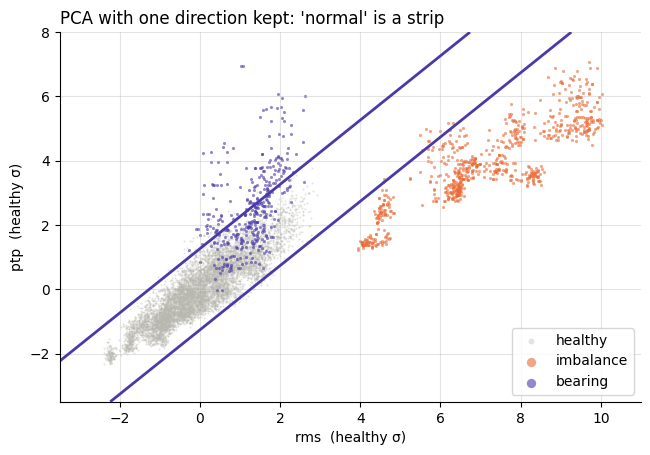

bearing caught:   43%
imbalance caught: 98%


In [16]:
dp = D.PCAResidual(k=1).fit(X2[NRM]); sp = dp.score(X2)      # keep ONE direction
kp = np.quantile(sp[NRM], 0.99)

gxw, gyw = np.meshgrid(np.linspace(-3.5, 11, 300), np.linspace(-3.5, 8, 300))
gridw = np.column_stack([gxw.ravel(), gyw.ravel()]) * sd2 + mu2

fig, ax = plt.subplots(figsize=(7.5, 4.8))
cloud(ax)
ax.contour(gxw, gyw, dp.score(gridw).reshape(gxw.shape), levels=[kp],
           colors=[VIOLET], linewidths=2)
ax.set_xlim(-3.5, 11); ax.set_ylim(-3.5, 8); ax.legend(markerscale=3, loc="lower right")
ax.set_title("PCA with one direction kept: 'normal' is a strip", loc="left")
plt.show()

print(f"bearing caught:   {(sp[BRG] > kp).mean():.0%}")
print(f"imbalance caught: {(sp[IMB] > kp).mean():.0%}")

With one direction kept, "normal" is a **strip** along the cigar — and it **never ends**.
Anything that lies along that line, however far out, reconstructs perfectly and scores as
healthy. The bearing windows sit off the strip and are caught
(**43%**). In this 2-D view the imbalance windows happen to lie off it
too (**98%**).

(Why keep one direction and not 95 %? In two dimensions, 95 % of the variance needs both
directions — and if you keep every direction, nothing is left over and every residual is
zero. PCA only makes sense when you keep fewer directions than you have features.)

### Its blind spot, in twelve dimensions

On the full rig, PCA keeps **7 of 12** directions. And there, imbalance moves
mostly **along** the healthy directions — a bigger 1× shaft line is just "more of what a
healthy machine already does". So its residual stays small. That is why Lecture 10 found
the PCA residual catches only **0.557** of imbalance windows.

PCA gives you a second number for free, and Lecture 10 did not use it: **T²**, how far the
window sits *along* the kept directions, measured in their own standard deviations. It is
literally the Mahalanobis distance of section 3, computed inside the kept directions.

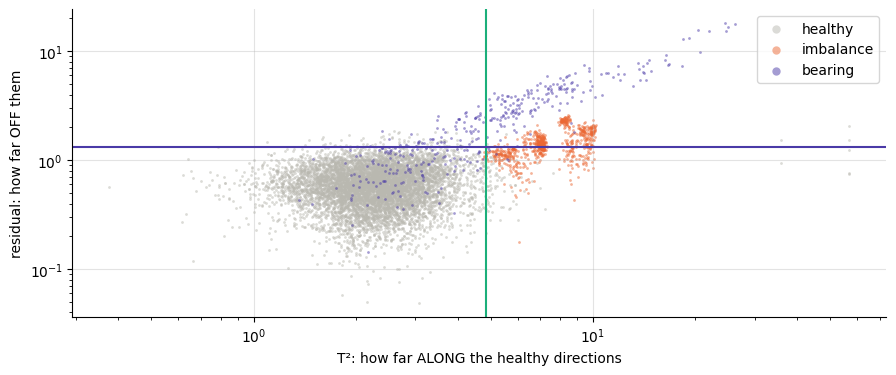

residual (Lecture 10)  bearing 0.637   imbalance 0.557
T²                     bearing 0.486   imbalance 0.992

median imbalance window: residual 1.04 x its threshold, T² 1.46 x its threshold


In [17]:
spe, t2 = oof["S"]["PCA residual"], oof["T2"]
ks, kt = np.quantile(spe[NRM], 0.99), np.quantile(t2[NRM], 0.99)

fig, ax = plt.subplots(figsize=(10.5, 4))
for m, col, lab in ((NRM, GREY, "healthy"), (IMB, ORANGE, "imbalance"),
                    (BRG, VIOLET, "bearing")):
    ax.scatter(t2[m], spe[m], s=4, c=col, alpha=0.5, lw=0, label=lab)
ax.axvline(kt, color=AQUA); ax.axhline(ks, color=VIOLET)
ax.set_xscale("log"); ax.set_yscale("log"); ax.legend(markerscale=3)
ax.set_xlabel("T²: how far ALONG the healthy directions")
ax.set_ylabel("residual: how far OFF them")
plt.show()

for name, v, k in (("residual (Lecture 10)", spe, ks), ("T²", t2, kt)):
    print(f"{name:<22} bearing {(v[BRG] > k).mean():.3f}   "
          f"imbalance {(v[IMB] > k).mean():.3f}")
print(f"\nmedian imbalance window: residual {np.median(spe[IMB]) / ks:.2f} x its threshold, "
      f"T² {np.median(t2[IMB]) / kt:.2f} x its threshold")

The two halves of PCA see different faults:

| | bearing | imbalance |
|---|---|---|
| residual (off the healthy directions) | **0.637** | 0.557 |
| T² (along them) | 0.486 | **0.992** |

The median imbalance window has a residual only 1.04× the
threshold — right on the line — but a T² of 1.46×. It is not
doing anything new; it is doing something ordinary, far too much. The residual cannot see
that. T² can. Industrial PCA monitoring normally watches **both**, with a threshold on each.

## 6. Four shapes of "normal"

Put the four side by side on the same data, each at its own 99th-percentile threshold:

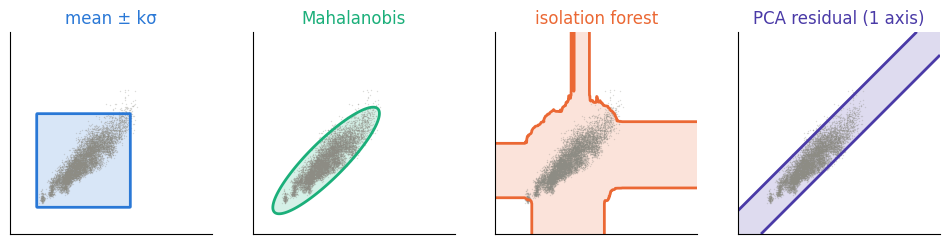

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.4))
gx4, gy4 = np.meshgrid(np.linspace(-4, 7, 240), np.linspace(-4, 7, 240))
g4 = np.column_stack([gx4.ravel(), gy4.ravel()]) * sd2 + mu2
for a, (name, det, k, col) in zip(axes, (("mean ± kσ", dz, kz, BLUE),
                                         ("Mahalanobis", dm, km, AQUA),
                                         ("isolation forest", di, ki, ORANGE),
                                         ("PCA residual (1 axis)", dp, kp, VIOLET))):
    Sg = det.score(g4).reshape(gx4.shape)
    a.contourf(gx4, gy4, (Sg <= k).astype(float), levels=[0.5, 1.5], colors=[col], alpha=0.18)
    a.contour(gx4, gy4, Sg, levels=[k], colors=[col], linewidths=2)
    a.scatter(Z2[NRM, 0], Z2[NRM, 1], s=1, c="#8d8c84", alpha=0.3, lw=0)
    a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([]); a.set_title(name, color=col)
plt.show()

| method | "normal" is | it assumes | it misses |
|---|---|---|---|
| mean ± kσ | a box | each feature on its own | faults that are wrong *together* but fine *separately* |
| Mahalanobis | an ellipse | healthy data is one tilted, roughly elliptical cloud | clouds with several clusters or odd shapes |
| isolation forest | whatever the cuts carve out | nothing about shape | "how far" (it saturates); one-feature faults in many dimensions |
| PCA residual | a strip (a slab, in 12-D) | healthy variation lives in a few directions | faults that move *along* those directions |

The odd shape of the isolation-forest region is the saturation of section 4 made visible:
where the score has reached its ceiling it hovers around the threshold, and whether a patch
counts as "normal" is decided by noise.

## 7. On the rig: Lecture 10's table, reproduced — plus the two it did not have

Everything above used two features for the pictures. Now all twelve, with Lecture 10's
exact protocol: five grouped folds, each detector fitted only on the healthy windows of
the *other* folds' runs, threshold at the 99th percentile of healthy scores.

In [19]:
from sklearn.metrics import roc_auc_score

rows = D.summary(oof["S"], y)
faulty = (~NRM).astype(int)
rows["PCA T²"] = {"auc": roc_auc_score(faulty, t2),
                  "bearing": float((t2[BRG] > kt).mean()),
                  "imbalance": float((t2[IMB] > kt).mean())}

print(f"{'detector':<18}{'ROC-AUC':>9}{'bearing':>10}{'imbalance':>11}")
for k, r in rows.items():
    tag = "   <- not in Lecture 10" if k in ("Mahalanobis", "PCA T²") else ""
    print(f"{k:<18}{r['auc']:9.3f}{r['bearing']:10.3f}{r['imbalance']:11.3f}{tag}")

detector            ROC-AUC   bearing  imbalance
mean ± kσ             0.959     0.514      0.993
Mahalanobis           0.972     0.631      1.000   <- not in Lecture 10
isolation forest      0.963     0.577      0.954
PCA residual          0.943     0.637      0.557
PCA T²                0.959     0.486      0.992   <- not in Lecture 10


The three Lecture 10 rows match its slides to the third decimal. Two things are new:

* **Mahalanobis beats all three** — AUC 0.972, bearing
  0.631, imbalance 1.000. On this rig the healthy
  data really is one correlated cloud, so the method that assumes exactly that wins. It
  costs 12 means, 12 standard deviations and a 12×12 matrix — 168 numbers, still small
  enough for the ESP32.
* **T² and the residual are complementary.** Neither is best on its own; together they
  would cover both fault types.

None of this makes Lecture 10's choice wrong. Lecture 11 deploys mean ± kσ because it is
25 numbers, it names the feature that tripped it — which Mahalanobis cannot do directly —
and 0.514 against 0.631 is inside the spread Lecture 10 measured across folds.

## 8. When "healthy" is not quite healthy

Every method in this notebook learns from windows you **believe** are healthy. In a real
plant you never know that for certain — a bearing may already be degrading when you
collect your baseline.

So: slip a small fraction of faulty windows into the training set, fit every detector,
and set the threshold at the 99th percentile of that training set — exactly as an
engineer would, believing it clean. Then test on held-out data.

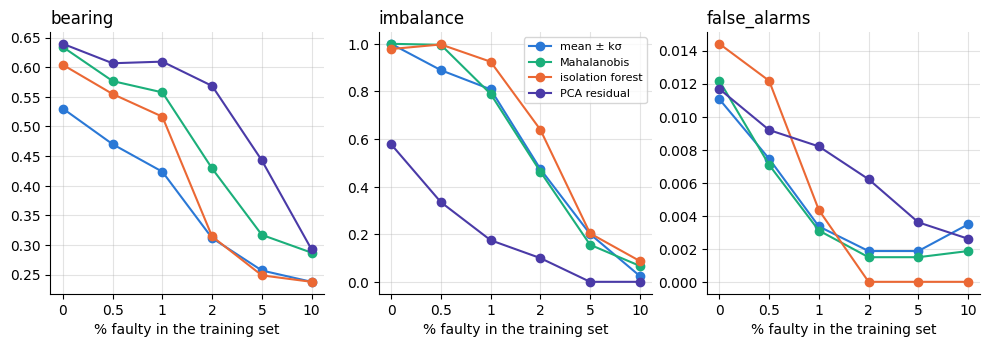

% faulty       mean ± kσ     Mahalanobis    isolation fo    PCA residual
       0     0.53 / 1.00     0.63 / 1.00     0.60 / 0.98     0.64 / 0.58
     0.5     0.47 / 0.89     0.58 / 1.00     0.55 / 1.00     0.61 / 0.33
       1     0.42 / 0.81     0.56 / 0.79     0.52 / 0.92     0.61 / 0.17
       2     0.31 / 0.47     0.43 / 0.46     0.31 / 0.64     0.57 / 0.10
       5     0.26 / 0.20     0.32 / 0.16     0.25 / 0.20     0.44 / 0.00
      10     0.24 / 0.02     0.29 / 0.07     0.24 / 0.09     0.29 / 0.00

(bearing recall / imbalance recall)


In [20]:
PS = [0.0, 0.005, 0.01, 0.02, 0.05, 0.10]
res = {}
for p in PS:
    o = D.oof_scores(X, y, groups, contamination=p)
    res[p] = {"fit": D.summary(o["S"], y, thr=o["fit_threshold"]),
              "clean": D.summary(o["S"], y), "thr": o["fit_threshold"]}

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
cols = {"mean ± kσ": BLUE, "Mahalanobis": AQUA, "isolation forest": ORANGE,
        "PCA residual": VIOLET}
for a, key in zip(ax, ("bearing", "imbalance", "false_alarms")):
    for k, c in cols.items():
        a.plot(range(len(PS)), [res[p]["fit"][k][key] for p in PS], "o-", color=c, label=k)
    a.set_xticks(range(len(PS))); a.set_xticklabels([f"{p*100:g}" for p in PS])
    a.set_xlabel("% faulty in the training set"); a.set_title(key, loc="left")
ax[1].legend(fontsize=8)
plt.show()

print(f"{'% faulty':>8}  " + "  ".join(f"{k[:12]:>14}" for k in cols))
for p in PS:
    print(f"{p*100:8g}  " + "  ".join(
        f"{res[p]['fit'][k]['bearing']:.2f} / {res[p]['fit'][k]['imbalance']:.2f}".rjust(14)
        for k in cols))
print("\n(bearing recall / imbalance recall)")

Three things happen, and the third is the dangerous one.

**The detectors go deaf fast.** At just **2 %** contamination, mean ± kσ falls from
0.53 / 1.00 (bearing / imbalance) to
**0.31 / 0.47**. At 5 %, no method
catches more than 20% of imbalance.

**The threshold is the first casualty.** A 99th percentile is, by definition, set by the
top 1 % of the training data. Once more than 1 % of that data is faulty, **the threshold is
set by the faults themselves**. For mean ± kσ it climbs from k =
3.92 to k = **5.42** at 2 %.

In [21]:
p = 0.02
print(f"at {p:.0%} contamination:              bearing   imbalance")
for k in cols:
    a_, b_ = res[p]["clean"][k], res[p]["fit"][k]
    print(f"  {k:<18} clean threshold  {a_['bearing']:.3f}     {a_['imbalance']:.3f}")
    print(f"  {'':<18} its own threshold {b_['bearing']:.3f}     {b_['imbalance']:.3f}")

at 2% contamination:              bearing   imbalance
  mean ± kσ          clean threshold  0.464     0.831
                     its own threshold 0.311     0.474
  Mahalanobis        clean threshold  0.568     0.810
                     its own threshold 0.429     0.463
  isolation forest   clean threshold  0.552     0.936
                     its own threshold 0.314     0.639
  PCA residual       clean threshold  0.582     0.113
                     its own threshold 0.568     0.100


Splitting the two effects: the contaminated *model* costs some recall, and the contaminated
*threshold* costs the rest. PCA is the odd one out — even with a clean threshold its
imbalance recall is only 0.113, because the faulty windows
pulled a principal direction towards themselves and the fault now **reconstructs**. The
isolation forest's *model* is the most robust (0.936 with a
clean threshold), which is what it is known for — but its threshold creeps like everyone
else's.

**And the dangerous part: the false-alarm rate goes DOWN** — from about
1.1 % to 0.2 % for
mean ± kσ. The number you would watch to check your detector gets *better* while the
detector goes deaf. This is the same trap as Lecture 12's "refit on everything recent":
best on false alarms, worst as a detector.

The defence is not a cleverer method. It is procedure:

* **exclude anything that alarmed** before it joins the baseline — Lecture 10's drift fix
  used exactly this rule (a month joins only if its alarm rate was below 0.20);
* **re-measure detection**, not just false alarms, every time you refit;
* be suspicious of a false-alarm rate that improves for no reason.

## 9. Which one?

| | mean ± kσ | Mahalanobis | isolation forest | PCA residual (+ T²) |
|---|---|---|---|---|
| numbers to store | 25 | 168 | 200 trees — kilobytes to megabytes | ~110 |
| fits on an ESP32 | yes | yes | no — cloud | yes |
| names the feature that tripped | **yes** | no | no | partly (residual per feature) |
| handles correlated features | no | **yes** | partly | **yes** |
| assumes a shape | box | ellipse | none | a few directions |
| says "how far" | yes | yes | **no — saturates** | yes |
| blind to | faults wrong only *together* | multi-cluster data | one-feature faults | faults *along* healthy directions (residual only) |
| on this rig, bearing / imbalance | 0.514 / 0.993 | 0.631 / 1.000 | 0.577 / 0.954 | 0.637 / 0.557 |

A reasonable default for a machine like this one: **mean ± kσ on the device** — cheap, and
it tells the technician which feature — and **Mahalanobis or PCA with T² in the cloud**,
where the extra numbers cost nothing and the correlations are worth catching.

## 10. What to remember

1. **Score, then threshold.** The method gives the score; the threshold is yours, and it is
   a quantile of healthy scores, never a textbook "3σ".
2. **mean ± kσ is a box.** It judges each feature separately and cannot see features that
   are wrong together.
3. **Mahalanobis is an ellipse.** It judges them together. On correlated data it wins; it
   needs an invertible (or pseudo-inverted) correlation matrix.
4. **The isolation forest counts random cuts.** It assumes no shape, it saturates — it
   knows *outside*, not *how far* — and it is weak on faults that show in one feature.
5. **PCA's residual is a strip.** It sees faults that go *off* the healthy directions and
   misses faults that go *along* them. T² is the other half; use both.
6. **Contamination is the real enemy.** A few percent of faulty windows in your baseline
   deafens every method, and the false-alarm rate improves while it happens. Exclude what
   alarmed; re-measure detection.

## 11. Exercises

**1. Your own k.** Compute the 99th-percentile threshold of max |z| using only the seven
time-domain features, and then only the five frequency-domain ones. Which set needs the
larger k, and which features are responsible? (Hint: look at the skew.)

**2. Draw the box and the ellipse for a different pair.** Repeat sections 2–3 for `crest`
against `kurt`, whose healthy correlation is also high. Does Mahalanobis help as much?
Explain the answer from the scatter plot before you compute it.

**3. Find the driver.** `ZScore.driver()` returns the feature furthest out for each window.
Tabulate the drivers for caught bearing windows and caught imbalance windows. Are they the
features you would expect from the physics in Lecture 8?

**4. Break the isolation forest's ceiling.** Refit the 2-D forest with
`max_samples=len(healthy)` instead of 256. What happens to the ceiling, the threshold, and
the bearing recall? Why does a bigger sample raise the ceiling?

**5. Watch both halves of PCA.** Build a combined PCA detector that alarms if **either** the
residual or T² exceeds its threshold. To keep the total false-alarm rate at 1 %, what
quantile must each threshold use? Report bearing and imbalance recall.

**6. How many directions?** Rerun the PCA residual on the rig keeping 3, 5, 7, 9 and 11
directions. Plot bearing and imbalance recall against the number kept, and explain the
shape of each curve in one sentence.

**7. A robust baseline.** Replace the mean and standard deviation in `ZScore` with the
median and the median absolute deviation (×1.4826). Rerun the contamination sweep. Which
part of the damage does it repair — the model or the threshold?

**8. The one-feature fault.** Section 4 showed the isolation forest missing a window that
is 50σ out on one feature. Name a real failure on this rig — a sensor fault counts — that
would look like that, and say which of the four detectors you would trust to catch it.

## 12. References

* Liu, F. T., Ting, K. M. and Zhou, Z.-H. (2008). "Isolation forest." *Proceedings of the
  8th IEEE International Conference on Data Mining (ICDM)*, 413–422. The original paper;
  section 2 is the cutting game.
* Mahalanobis, P. C. (1936). "On the generalised distance in statistics." *Proceedings of
  the National Institute of Sciences of India*, 2(1), 49–55.
* Jackson, J. E. and Mudholkar, G. S. (1979). "Control procedures for residuals associated
  with principal component analysis." *Technometrics*, 21(3), 341–349. Where the residual
  (Q) statistic and its threshold come from.
* MacGregor, J. F. and Kourti, T. (1995). "Statistical process control of multivariate
  processes." *Control Engineering Practice*, 3(3), 403–414. PCA monitoring with T² and Q
  together, in industry.
* Chandola, V., Banerjee, A. and Kumar, V. (2009). "Anomaly detection: a survey."
  *ACM Computing Surveys*, 41(3), 15.
* Montgomery, D. C. (2019). *Introduction to Statistical Quality Control*, 8th ed. Wiley.
  Chapters 6 and 11: where "3σ" comes from, and why it assumes a Gaussian.
* scikit-learn user guide, "Novelty and outlier detection":
  https://scikit-learn.org/stable/modules/outlier_detection.html